In [1]:
BUFFER = 60

# Augmentation

In [2]:
import random
import numpy as np


def is_palm_static(data, hand='right', threshold=0.2):
    """
    data: [frames, 165]
    threshold: порог чувствительности (подбирается экспериментально)
    """
    # 1. Извлекаем только точки ладони (21 точка по 3 координаты = 63 значения)
    # По MediaPipe это индексы с 0 по 20 (если данные начинаются с руки)
    # В твоем случае срез 13*3:21*3 (если это индексы внутри 165)
    if hand=='left':
        palm_points = data[:, 13*3:34*3] 
    elif hand=='right':
        palm_points = data[:, 34*3:55*3] 
    else:
        return False
    
    # 2. Считаем, насколько сильно "гуляют" координаты во времени
    # axis=0 — считаем отклонение по кадрам для каждого признака
    std_dev = np.std(palm_points, axis=0)
    
    # 3. Находим среднее отклонение по всем точкам ладони
    avg_movement = np.mean(std_dev)
    
    # Если среднее движение меньше порога — ладонь статична
    return avg_movement < threshold


def invert(data):
    data_lh = data[:, 13*3:34*3].copy()
    data_rh = data[:, 34*3:55*3].copy()

    data[:, 13*3:34*3], data[:, 34*3:55*3] = data_rh, data_lh

    swaps = ((1, 2), (3, 4), (5, 6), (7, 8), (9, 10), (11, 12))
    for swap in swaps:
        d1 = data[:, swap[0]*3:(swap[0]+1)*3].copy()
        d2 = data[:, swap[1]*3:(swap[1]+1)*3].copy()
        data[:, swap[0]*3:(swap[0]+1)*3], data[:, swap[1]*3:(swap[1]+1)*3] = d2, d1

    data[:, 0:165:3] *= -1
    return data

def center_hadns(data):
    data_lh = data[:, 13*3:34*3].copy()
    data_rh = data[:, 34*3:55*3].copy()

    data[:, 13*3:34*3:3] = data_lh[:, 0::3] - data[:, 13*3, np.newaxis]
    data[:, 13*3+1:34*3:3] = data_lh[:, 1::3] - data[:, 13*3+1, np.newaxis]
    data[:, 13*3+2:34*3:3] = data_lh[:, 2::3] - data[:, 13*3+2, np.newaxis]

    data[:, 34*3:55*3:3] = data_rh[:, 0::3] - data[:, 34*3, np.newaxis]
    data[:, 34*3+1:55*3:3] = data_rh[:, 1::3] - data[:, 34*3+1, np.newaxis]
    data[:, 34*3+2:55*3:3] = data_rh[:, 2::3] - data[:, 34*3+2, np.newaxis]


    return data

def letter_augmentation(data, inv=False):
    if inv:
        data = invert(data)

    # scale
    scale = (random.random() - 0.5) * 0.25 + 1
    data[:, :] *= scale

    # rotate l hand
    data_hand = data[:, 13*3:34*3]

    center = data[:, 13*3:14*3].copy()

    x = data_hand[:, 0::3] - center[:, 0, np.newaxis]
    y = data_hand[:, 1::3] - center[:, 1, np.newaxis]
    z = data_hand[:, 2::3] - center[:, 2, np.newaxis]
    
    theta = np.radians((random.random()-0.5)*20) # rotate z
    c, s = np.cos(theta), np.sin(theta)
    temp1_x = c * x - s * y
    temp1_y = s * x + c * y
    temp1_z = z

    theta = np.radians((random.random()-0.5)*20) # rotate x
    c, s = np.cos(theta), np.sin(theta)
    temp2_x = temp1_x
    temp2_y = c * temp1_y - s * temp1_z
    temp2_z = s * temp1_y + c * temp1_z

    theta = np.radians((random.random()-0.5)*20) # rotate y
    c, s = np.cos(theta), np.sin(theta)
    temp3_x = c * temp2_x + s * temp2_z
    temp3_y = temp2_y
    temp3_z = - s * temp2_x + c * temp2_z

    data_hand[:, 0::3], data_hand[:, 1::3], data_hand[:, 2::3] = temp3_x, temp3_y, temp3_z

    data_hand[:, 0::3] += center[:, 0, np.newaxis]
    data_hand[:, 1::3] += center[:, 1, np.newaxis]
    data_hand[:, 2::3] += center[:, 2, np.newaxis]  


    # rotate r hand
    data_hand = data[:, 34*3:55*3]

    center = data[:, 34*3:35*3].copy()

    x = data_hand[:, 0::3] - center[:, 0, np.newaxis]
    y = data_hand[:, 1::3] - center[:, 1, np.newaxis]
    z = data_hand[:, 2::3] - center[:, 2, np.newaxis]
    
    theta = np.radians((random.random()-0.5)*20) # rotate z
    c, s = np.cos(theta), np.sin(theta)
    temp1_x = c * x - s * y
    temp1_y = s * x + c * y
    temp1_z = z

    theta = np.radians((random.random()-0.5)*20) # rotate x
    c, s = np.cos(theta), np.sin(theta)
    temp2_x = temp1_x
    temp2_y = c * temp1_y - s * temp1_z
    temp2_z = s * temp1_y + c * temp1_z

    theta = np.radians((random.random()-0.5)*20) # rotate y
    c, s = np.cos(theta), np.sin(theta)
    temp3_x = c * temp2_x + s * temp2_z
    temp3_y = temp2_y
    temp3_z = - s * temp2_x + c * temp2_z

    data_hand[:, 0::3], data_hand[:, 1::3], data_hand[:, 2::3] = temp3_x, temp3_y, temp3_z

    data_hand[:, 0::3] += center[:, 0, np.newaxis]
    data_hand[:, 1::3] += center[:, 1, np.newaxis]
    data_hand[:, 2::3] += center[:, 2, np.newaxis]  


    return data

In [145]:
import random


def rotate_data(data, center, angle=20):

    x = data[:, 0::3] - center[:, 0, np.newaxis]
    y = data[:, 1::3] - center[:, 1, np.newaxis]
    z = data[:, 2::3] - center[:, 2, np.newaxis]
    
    theta = np.radians((random.random()-0.5)*angle) # rotate z
    c, s = np.cos(theta), np.sin(theta)
    temp1_x = c * x - s * y
    temp1_y = s * x + c * y
    temp1_z = z

    theta = np.radians((random.random()-0.5)*angle) # rotate x
    c, s = np.cos(theta), np.sin(theta)
    temp2_x = temp1_x
    temp2_y = c * temp1_y - s * temp1_z
    temp2_z = s * temp1_y + c * temp1_z

    theta = np.radians((random.random()-0.5)*angle) # rotate y
    c, s = np.cos(theta), np.sin(theta)
    temp3_x = c * temp2_x + s * temp2_z
    temp3_y = temp2_y
    temp3_z = - s * temp2_x + c * temp2_z

    data[:, 0::3] = temp3_x + center[:, 0, np.newaxis]
    data[:, 1::3] = temp3_y + center[:, 1, np.newaxis]
    data[:, 2::3] = temp3_z + center[:, 2, np.newaxis]  

    return data


def augmentation(data, inv=False):
    if inv:
        data = invert(data)

    # data_lh = data[:, 13*3:34*3]
    # data_rh = data[:, 34*3:55*3]

    # off_l = data_lh[:, 2] - data[:, 7*3+2]
    # off_r = data_rh[:, 2] - data[:, 8*3+2]
    

    # data_lh[:, 2::3] -= off_l[:, np.newaxis]

    # data_rh[:, 2::3] -= off_r[:, np.newaxis]


    # # rotate left hand 1

    # theta = np.radians((np.random.random() - 0.5) * 90)
    # c, s = np.cos(theta), np.sin(theta)

    # h_start, h_end = 13*3, 34*3
    # center = data[:, 13*3 : (13+1)*3]  # [Frames, 3]
    # e_raw = data[:, (5)*3 : (6)*3] - data[:, (7)*3 : (8)*3]  # [Frames, 3]

    # norm = np.linalg.norm(e_raw, axis=1, keepdims=True) + 1e-9
    # e = e_raw / norm  # [Frames, 3]

    # points = data[:, h_start:h_end].reshape(-1, 21, 3)

    # v = points - center[:, np.newaxis, :]

    # k_cross_v = np.cross(e[:, np.newaxis, :], v, axis=-1)
    # k_dot_v = np.einsum('fi,fji->fj', e, v) # [Frames, 21]
    # k_k_dot_v = k_dot_v[:, :, np.newaxis] * e[:, np.newaxis, :] # [Frames, 21, 3]
    # v_rot = v * c + k_cross_v * s + k_k_dot_v * (1 - c)

    # data[:, h_start:h_end] = (v_rot + center[:, np.newaxis, :]).reshape(data.shape[0], -1)

    # # rotate left hand 2

    # theta = np.radians((np.random.random() - 0.5) * 90)
    # c, s = np.cos(theta), np.sin(theta)

    # h_start, h_end = 13*3, 34*3
    # center = data[:, 13*3 : (13+1)*3]  # [Frames, 3]
    # e_raw = data[:, (13+5)*3 : (13+6)*3] - data[:, (13+17)*3 : (13+18)*3]  # [Frames, 3]

    # norm = np.linalg.norm(e_raw, axis=1, keepdims=True) + 1e-9
    # e = e_raw / norm  # [Frames, 3]

    # points = data[:, h_start:h_end].reshape(-1, 21, 3)

    # v = points - center[:, np.newaxis, :]

    # k_cross_v = np.cross(e[:, np.newaxis, :], v, axis=-1)
    # k_dot_v = np.einsum('fi,fji->fj', e, v) # [Frames, 21]
    # k_k_dot_v = k_dot_v[:, :, np.newaxis] * e[:, np.newaxis, :] # [Frames, 21, 3]
    # v_rot = v * c + k_cross_v * s + k_k_dot_v * (1 - c)

    # data[:, h_start:h_end] = (v_rot + center[:, np.newaxis, :]).reshape(data.shape[0], -1)


    # # rotate right hand 1
    # theta = np.radians((np.random.random() - 0.5) * 90)
    # c, s = np.cos(theta), np.sin(theta)

    # h_start, h_end = 34*3, 55*3
    # center = data[:, 34*3 : (34+1)*3]  # [Frames, 3]
    # e_raw = data[:, (6)*3 : (7)*3] - data[:, (8)*3 : (9)*3]  # [Frames, 3]

    # norm = np.linalg.norm(e_raw, axis=1, keepdims=True) + 1e-9
    # e = e_raw / norm  # [Frames, 3]

    # points = data[:, h_start:h_end].reshape(-1, 21, 3)

    # v = points - center[:, np.newaxis, :]

    # k_cross_v = np.cross(e[:, np.newaxis, :], v, axis=-1)
    # k_dot_v = np.einsum('fi,fji->fj', e, v) # [Frames, 21]
    # k_k_dot_v = k_dot_v[:, :, np.newaxis] * e[:, np.newaxis, :] # [Frames, 21, 3]
    # v_rot = v * c + k_cross_v * s + k_k_dot_v * (1 - c)

    # data[:, h_start:h_end] = (v_rot + center[:, np.newaxis, :]).reshape(data.shape[0], -1)

    # # rotate right hand 2
    # theta = np.radians((np.random.random() - 0.5) * 90)
    # c, s = np.cos(theta), np.sin(theta)

    # h_start, h_end = 34*3, 55*3
    # center = data[:, 34*3 : (34+1)*3]  # [Frames, 3]
    # e_raw = data[:, (34+5)*3 : (34+6)*3] - data[:, (34+17)*3 : (34+18)*3]  # [Frames, 3]

    # norm = np.linalg.norm(e_raw, axis=1, keepdims=True) + 1e-9
    # e = e_raw / norm  # [Frames, 3]

    # points = data[:, h_start:h_end].reshape(-1, 21, 3)

    # v = points - center[:, np.newaxis, :]

    # k_cross_v = np.cross(e[:, np.newaxis, :], v, axis=-1)
    # k_dot_v = np.einsum('fi,fji->fj', e, v) # [Frames, 21]
    # k_k_dot_v = k_dot_v[:, :, np.newaxis] * e[:, np.newaxis, :] # [Frames, 21, 3]
    # v_rot = v * c + k_cross_v * s + k_k_dot_v * (1 - c)

    # data[:, h_start:h_end] = (v_rot + center[:, np.newaxis, :]).reshape(data.shape[0], -1)
    

    # rotate elbows     
    d = rotate_data(np.concat([data[:, 13*3:34*3], data[:, 7*3:8*3]], axis=1), 
                data[:, 5*3:6*3].copy(), 20)
    data[:, 13*3:34*3], data[:, 7*3:8*3] = d[:, 0*3:21*3], d[:, 21*3:22*3]

    d = rotate_data(np.concat([data[:, 34*3:55*3], data[:, 8*3:9*3]], axis=1), 
                data[:, 5*3:6*3].copy(), 20)
    data[:, 34*3:55*3], data[:, 8*3:9*3] = d[:, 0*3:21*3], d[:, 21*3:22*3]

    # rotate hands
    data[:, 13*3:34*3] = rotate_data(data[:, 13*3:34*3], data[:, 13*3:14*3].copy(), 40)
    data[:, 34*3:55*3] = rotate_data(data[:, 34*3:55*3], data[:, 34*3:35*3].copy(), 40)

    # # move hands
    # move = [(random.random() - 0.5) * 0.5 for i in range(3)]

    # data_hands[:, 0::3] += move[0]
    # data_hands[:, 1::3] += move[1]
    # # data_hands[:, 2::3] += move[2]

    # # cutoff
    # c = random.random()
    # if c > 0.5:
    #     c *= BUFFER
    #     for i in range(BUFFER):
    #         if i > c:
    #             data[i] = data[i-1]


    # move
    move = [(random.random() - 0.5) * 0.3 for i in range(2)]

    data[:, 0:165:3] += move[0]
    data[:, 1:165:3] += move[1]
    
    # scale
    scale = (random.random() - 0.5) * 0.25 + 1
    data[:, :] *= scale

    # rotate
    new_ind = random.randint(0, 5)
    x = data[:, 0:165:3]
    y = data[:, 1:165:3]
    z = data[:, 2:165:3]

    theta = np.radians(random.random()*30)
    if new_ind%2==0:
        theta *= -1

    c, s = np.cos(theta), np.sin(theta)

    if new_ind//2 == 0: # rotate x
        new_y = c * y - s * z
        new_z = s * y + c * z
        data[:, 1:165:3], data[:, 2:165:3] = new_y, new_z
    if new_ind//2 == 1: # rotate y
        new_x = c * x + s * z
        new_z = - s * x + c * z
        data[:, 0:165:3], data[:, 2:165:3] = new_x, new_z
    if new_ind//2 == 2: # rotate z
        new_x = c * x - s * y
        new_y = s * x + c * y
        data[:, 0:165:3], data[:, 1:165:3] = new_x, new_y

    # speed
    ind = 0
    offset = int((random.random() - 0.5) * 20)
    if abs(offset) > 1:
        data_new = data.copy()
        for i in range(BUFFER):
            if ind==BUFFER:
                break
            if i%offset==0:
                if offset > 0:
                    data_new[ind] = data_new[ind-1]
                    ind += 1
                    if ind==BUFFER:
                        break
                    data_new[ind] = data[i]
                    ind += 1
                else:
                    continue
            else:
                data_new[ind] = data[i]
                ind += 1

        while ind<BUFFER:
            data_new[ind] = data_new[ind-1]
            ind += 1

        data = data_new


    # if is_palm_static(data, 'left'):
    #     r = random.random()
    #     if r > 0.6:
    #         data[:, 13*3:34*3] = np.zeros(data[:, 13*3:34*3].shape)

    # if is_palm_static(data, 'right'):
    #     r = random.random()
    #     if r > 0.6:
    #         data[:, 34*3:55*3] = np.zeros(data[:, 34*3:55*3].shape)

    # r = random.random()
    # if r > 0.5:
    #     data = data[:-1, :]

    
    return data

In [ ]:
import numpy as np

dataset = np.memmap(f"../tracking/{BUFFER}/train.bin", dtype='float32', mode='r', shape=(len(test_classes), BUFFER, 165))

In [234]:
a = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
a.reshape(4, 3)

array([[ 1,  2,  3],
       [ 4,  5,  6],
       [ 7,  8,  9],
       [10, 11, 12]])

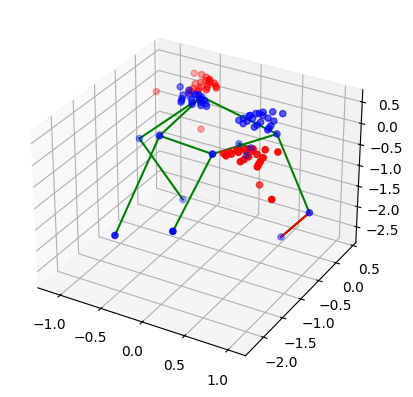

In [287]:
from matplotlib import pyplot as plt

# d = augmentation(dataset[1362].copy())[0].reshape(55, 3)
d = dataset[1400][20].reshape(55, 3)
fig  = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.axis('equal')

ax.scatter3D(d[:, 0], -d[:, 1], d[:, 2], c='blue')


conn = ((0,1), (1,2), (0,2), (3,4), (5,3), (4,6), 
        (4,10), (9, 10), (3,9), (12,10), (11,9), 
        (6,8), (5,7))

for elem in conn:
    ax.plot3D( [d[elem[0]][0], d[elem[1]][0]],
            [-d[elem[0]][1], -d[elem[1]][1]],
            [d[elem[0]][2], d[elem[1]][2]], 'green')
    
ax.plot3D([d[5][0], d[7][0]], [-d[5][1], -d[7][1]], [d[5][2], d[7][2]], color='red')

d = augmentation(dataset[1400].copy())[20].reshape(55, 3)
# d = data[20].reshape(55, 3)

ax.scatter3D(d[13:55, 0], -d[13:55, 1], d[13:55, 2], c='red')
ax.scatter3D(d[5:9, 0], -d[5:9, 1], d[5:9, 2], c='red')


# conn = ((0,1), (1,2), (0,2), (3,4), (5,3), (4,6), 
#         (4,10), (9, 10), (3,9), (12,10), (11,9), 
#         (6,8), (5,7))

# for elem in conn:
#     ax.plot3D( [d[elem[0]][0], d[elem[1]][0]],
#             [-d[elem[0]][1], -d[elem[1]][1]],
#             [d[elem[0]][2], d[elem[1]][2]], 'green')

plt.show()

In [248]:
%timeit augmentation(dataset[22].copy())

527 μs ± 3.57 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


# Tensorflow

In [4]:
import tensorflow as tf
import keras
import os

print(f"Версия TensorFlow: {tf.__version__}")
print(f"Построен с поддержкой CUDA: {tf.test.is_built_with_cuda()}")
print(f"Доступные GPU: {tf.config.list_physical_devices('GPU')}")

# Проверка библиотек в путях системы
cuda_path = os.environ.get('CUDA_PATH')
print(f"Путь к CUDA в системе: {cuda_path}")

2026-04-20 22:45:13.460970: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-20 22:45:13.777964: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776714313.889122  127912 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776714313.921051  127912 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776714314.175195  127912 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Версия TensorFlow: 2.19.1
Построен с поддержкой CUDA: True
Доступные GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Путь к CUDA в системе: None


In [5]:
@keras.saving.register_keras_serializable()
class SparseFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        # 1. Считаем стандартную кросс-энтропию
        y_true = tf.cast(y_true, tf.int32)
        scce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        
        # 2. Получаем вероятность предсказанного (правильного) класса
        # Мы используем gather_nd, чтобы вытащить p_t для каждого примера
        batch_size = tf.shape(y_pred)[0]
        range_idx = tf.range(batch_size)
        indices = tf.stack([range_idx, tf.reshape(y_true, [-1])], axis=1)
        p_t = tf.gather_nd(y_pred, indices)
        
        # 3. Формула Focal Loss: (1 - p_t)^gamma * log(p_t)
        focal_modulation = tf.pow(1.0 - p_t, self.gamma)
        loss = focal_modulation * scce
        
        return tf.reduce_mean(loss)

In [219]:
import numpy as np
from keras.utils import Sequence
from datetime import datetime as dt
 

class GestureBootstrapGenerator(Sequence):
    def __init__(self, dataset_path, classes, batch_size=32, generate=True, is_test=False, aug=False, aug_func=None, num_classes=3, **kwargs):
        self.dataset = np.memmap(dataset_path, dtype='float32', mode='r', shape=(len(classes), BUFFER, 165))
        self.classes = classes
        self.num_classes = num_classes
        self.len_classes = []

        for n_class in range(num_classes):
            self.len_classes.append(classes.count(n_class))

        self.batch_size = batch_size
        self.generate = generate
        self.aug = aug
        self.aug_func = aug_func
        self.is_test = is_test
        self.on_epoch_end()
        super().__init__(**kwargs)


    def __len__(self):
        return int(np.ceil(len(self.classes) / self.batch_size))


    def __getitem__(self, index):
        if self.generate:
            X = np.empty(shape=(self.batch_size, BUFFER, 165))  
            y_class = np.zeros((self.batch_size, self.num_classes), dtype='float32')

            for i in range(self.batch_size):

                cur_class = random.randint(0, self.num_classes-1)

                class_ind_start = sum(self.len_classes[:cur_class])
                class_ind_end = class_ind_start + self.len_classes[cur_class]

                rand_ind = random.randint(class_ind_start, class_ind_end-1)
                rand_inv = random.random()

                d = self.dataset[rand_ind].copy()
                if self.aug:
                    d = self.aug_func(d, rand_inv > 0.5)

                X[i] = d
                y_class[i][cur_class] = 1

            return X, y_class
        
        else:
            indexes = range(index * self.batch_size, min( (index + 1) * self.batch_size, len(self.classes)) )
            curr_batch_size = len(indexes)

            X = np.empty(shape=(curr_batch_size, BUFFER, 165))  
            y_class = np.zeros((curr_batch_size, self.num_classes), dtype='float32')    

            for i, ind in enumerate(indexes):
                X[i] = self.dataset[ind].copy()
                y_class[i][self.classes[ind]] = 1 

            return X, y_class  


# Model

## Data

In [138]:
letters = []
with open("../dataset/letters.txt", 'r') as f:
    letters = [w.replace("\n", "") for w in f.readlines()]

In [139]:
bad_words = []
with open("../dataset/bad_words.txt", 'r') as f:
    bad_words = [w.replace("\n", "") for w in f.readlines()]

In [140]:
import pandas as pd
import numpy as np

path = "../dataset/"

df = pd.read_csv(path+f"annotations{BUFFER}.csv", index_col=0)
mask = ((df["new_length"] > 73) & (df["new_length"] < 75))
# df_ = df[mask]
# new_uniq_words = df_["text"].unique()

n_train = n_test = 0

train_data = []
test_data = []

for i in range(len(df)):
    max_offset = max(int(df.loc[i, "new_length"])-BUFFER+1, 1)

    if df.loc[i, "text"] in letters:
        out_class = 0
    elif df.loc[i, "text"] in bad_words:
        out_class = 1
    else:
        out_class = 2
    # for offset in range(0, max_offset, max(max_offset, 5) // 5):
    for offset in range(0, max_offset):
        if df.loc[i, "train"]:
            train_data.append([f"../tracking/{BUFFER}/train/{df.loc[i, 'attachment_id']}.npy", out_class, offset])
        else:
            test_data.append([f"../tracking/{BUFFER}/test/{df.loc[i, 'attachment_id']}.npy", out_class, offset])



train_data_df = pd.DataFrame(data=train_data, 
                             columns=['path', 'class', 'offset']).sort_values("class")
test_data_df = pd.DataFrame(data=test_data,
                            columns=['path', 'class', 'offset']).sort_values("class")


train_paths = list(train_data_df["path"])
train_class = list(train_data_df["class"])
train_offsets = list(train_data_df["offset"])

test_paths = list(test_data_df["path"])
test_class = list(test_data_df["class"])
test_offsets = list(test_data_df["offset"])

In [141]:
train_data_df["class"].unique().shape

(3,)

In [142]:
import numpy as np
from tqdm import tqdm

N_SAMPLES = len(train_paths)
shape = (N_SAMPLES, BUFFER, 165)

fp = np.memmap(f'../tracking/{BUFFER}/train-separation.bin', dtype='float32', mode='w+', shape=shape)

for i, path in tqdm(enumerate(train_paths)):
    data_all = np.load(path)
    fp[i] = data_all[train_offsets[i]].reshape(BUFFER, 165)
    
fp.flush()

57586it [01:04, 892.18it/s] 


In [143]:
N_SAMPLES = len(test_paths) 
shape = (N_SAMPLES, BUFFER, 165)

fp = np.memmap(f'../tracking/{BUFFER}/test-separation.bin', dtype='float32', mode='w+', shape=shape)

for i, path in tqdm(enumerate(test_paths)):
    data_all = np.load(path)
    fp[i] = data_all[test_offsets[i]].reshape(BUFFER, 165)
    
fp.flush()

18089it [00:10, 1657.36it/s]


## Model

In [244]:
import tensorflow as tf
from keras import layers, models, regularizers
import keras

@keras.saving.register_keras_serializable()
def get_deltas(x):
    delta = x[:, 1:, :] - x[:, :-1, :]
    # 2. Добавляем нулевой кадр в начало, чтобы вернуть длину 40
    # (иначе после diff останется 39 кадров)
    padding = tf.zeros_like(x[:, :1, :])
    velocity = tf.concat([padding, delta], axis=1) 

    # 3. Решейп для выделения (x, y, z) каждой из 55 точек
    # Используем динамический размер батча и кадров
    shape = tf.shape(velocity)
    # [Batch, 40, 55, 3]
    v_reshaped = tf.reshape(velocity, (shape[0], shape[1], -1, 3))
    
    # 4. L2-Нормализация направления
    # axis=-1 означает нормализацию вектора (x, y, z)
    # epsilon=1e-8 предотвращает деление на ноль в неподвижных кадрах
    v_normalized = tf.math.l2_normalize(v_reshaped, axis=-1, epsilon=1e-8)
    
    # 5. Возвращаем в исходный плоский вид [Batch, 40, 165]
    return tf.reshape(v_normalized, shape)

@keras.saving.register_keras_serializable()
def new_inputs(x):
    return x[:, :, 13*3:]

@keras.saving.register_keras_serializable()
class GlobalMinPool1D(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.keras.backend.min(inputs, axis=1)

@keras.saving.register_keras_serializable()
def centralize_hands(x):
    center_left = x[:, :, 13*3:14*3]  
    center_right = x[:, :, 34*3:35*3] 

    scale_pt_left = x[:, :, 13*3+27 : 13*3+30]
    scale_pt_right = x[:, :, 34*3+27 : 34*3+30]
    dist_left = tf.norm(scale_pt_left - center_left, axis=-1, keepdims=True) + 1e-8
    dist_right = tf.norm(scale_pt_right - center_right, axis=-1, keepdims=True) + 1e-8

    parts = []
    
    parts.append(x[:, :, :13*3])
    
    left_hand_centered = x[:, :, 13*3:34*3] - tf.tile(center_left, [1, 1, 21])
    left_hand_scaled = left_hand_centered / tf.tile(dist_left, [1, 1, 63])
    parts.append(left_hand_scaled)

    right_hand_centered = x[:, :, 34*3:55*3] - tf.tile(center_right, [1, 1, 21])
    right_hand_scaled = right_hand_centered / tf.tile(dist_right, [1, 1, 63])
    parts.append(right_hand_scaled)
        
    return tf.concat(parts, axis=-1)

@keras.saving.register_keras_serializable()
def inputs_without_body(x):
    new_x = tf.concat([x[:, :, :5*3], x[:, :, 13*3:]], axis=2)
    return new_x

@keras.saving.register_keras_serializable()
def std(x):
    return tf.math.reduce_std(x, axis=1)

def build_slr_model():
    inputs = layers.Input(shape=(BUFFER, 165), name="input")

    x = layers.Lambda(centralize_hands)(inputs)
    x = layers.Lambda(new_inputs)(x)

    new_x = layers.Lambda(inputs_without_body)(inputs)

    # deltas = layers.Lambda(get_deltas)(inputs)
    # # Соединяем координаты и скорость [BUFFER, 330]
    # x = layers.Concatenate()([inputs, deltas])

    x = layers.Bidirectional(layers.LSTM(1024, return_sequences=True))(inputs)
    x = layers.BatchNormalization()(x)
    # x = layers.SpatialDropout1D(0.5)(x)

    # conv = layers.Conv1D(165*2, kernel_size=5, dilation_rate=2, activation='elu')(x)
    # conv = layers.GlobalMaxPooling1D()(conv)

    avg_pool = layers.GlobalAveragePooling1D()(x)
    max_pool = layers.GlobalMaxPooling1D()(x)  
    std_pool = layers.Lambda(std)(x)
    combined = layers.Concatenate()([avg_pool, max_pool, std_pool])

    common = layers.Dense(4096, activation='elu')(combined)
    common = layers.BatchNormalization()(common)
    common = layers.Dropout(0.6)(common)

    common = layers.Dense(1024, activation='elu')(common)
    common = layers.BatchNormalization()(common)
    common = layers.Dropout(0.5)(common)

    common = layers.Dense(256, activation='elu')(common)
    common = layers.BatchNormalization()(common)
    common = layers.Dropout(0.4)(common)
        
    out_class = layers.Dense(3, activation="softmax", name="class_output")(common)
    
    model = models.Model(inputs=inputs, outputs=out_class)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.01),
        metrics=['accuracy'],
    )
    
    return model

In [239]:
train_gen = GestureBootstrapGenerator(f"../tracking/{BUFFER}/train-separation.bin", 
                                      train_class, num_classes=3,
                                      batch_size=256, generate=True, is_test=True,
                                      aug=True, aug_func=augmentation,
                                      use_multiprocessing=True, workers=6)
val_gen = GestureBootstrapGenerator(f"../tracking/{BUFFER}/test-separation.bin", 
                                     test_class, num_classes=3,
                                     batch_size=256, generate=True,
                                     aug=False,
                                     use_multiprocessing=True, workers=6)

test_gen = GestureBootstrapGenerator(f"../tracking/{BUFFER}/test-separation.bin", 
                                     test_class, num_classes=3,
                                     batch_size=256, generate=False,
                                     aug=False,
                                     use_multiprocessing=True, workers=6)

In [33]:
%timeit train_gen[22]

165 ms ± 5.89 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [240]:
train_gen.__len__()

225

In [245]:
model = build_slr_model()
model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 60, 165)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_13    │ (None, 60, 2048)  │  9,748,480 │ input[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 2048)  │      8,192 │ bidirectional_13… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 2048)      │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_59 (Lambda)  │ (None, 2048)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_34      │ (None, 6144)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ lambda_59[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 4096)      │ 25,169,920 │ concatenate_34[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4096)      │     16,384 │ dense_38[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_28          │ (None, 4096)      │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 1024)      │  4,195,328 │ dropout_28[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_39[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_29          │ (None, 1024)      │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_40 (Dense)    │ (None, 256)       │    262,400 │ dropout_29[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_40[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 3)         │        771 │ dropout_30[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 39,406,595 (150.32 MB)

 Trainable params: 39,391,747 (150.27 MB)

 Non-trainable params: 14,848 (58.00 KB)

In [246]:
with tf.device('/GPU:0'):
    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=75,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
        ],
    )

Epoch 1/75
225/225 ━━━━━━━━━━━━━━━━━━━━ 65s 259ms/step - accuracy: 0.6435 - loss: 0.8701 - val_accuracy: 0.4618 - val_loss: 0.9840 - learning_rate: 0.0010
Epoch 2/75
225/225 ━━━━━━━━━━━━━━━━━━━━ 61s 268ms/step - accuracy: 0.7360 - loss: 0.6281 - val_accuracy: 0.5614 - val_loss: 0.8630 - learning_rate: 0.0010
Epoch 3/75
225/225 ━━━━━━━━━━━━━━━━━━━━ 64s 281ms/step - accuracy: 0.7715 - loss: 0.5531 - val_accuracy: 0.7110 - val_loss: 0.6556 - learning_rate: 0.0010
Epoch 4/75
225/225 ━━━━━━━━━━━━━━━━━━━━ 58s 254ms/step - accuracy: 0.8018 - loss: 0.4932 - val_accuracy: 0.7087 - val_loss: 0.7841 - learning_rate: 0.0010
Epoch 5/75
225/225 ━━━━━━━━━━━━━━━━━━━━ 58s 257ms/step - accuracy: 0.8193 - loss: 0.4549 - val_accuracy: 0.6927 - val_loss: 0.7542 - learning_rate: 0.0010
Epoch 6/75
225/225 ━━━━━━━━━━━━━━━━━━━━ 59s 260ms/step - accuracy: 0.8530 - loss: 0.3882 - val_accuracy: 0.7159 - val_loss: 0.7804 - learning_rate: 5.0000e-04
Epoch 7/75
225/225 ━━━━━━━━━━━━━━━━━━━━ 57s 249ms/step - accuracy:

In [247]:
import joblib

joblib.dump(model, "../models/recognizing/gesture-separation-60-1.joblib")

['../models/recognizing/gesture-separation-60-1.joblib']

## Test

In [168]:
import joblib

loaded_model = joblib.load("../models/recognizing/gesture-separation-60-3.joblib")

In [248]:
loaded_model = model

In [169]:
loaded_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 60, 165)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_7     │ (None, 60, 1024)  │  2,777,088 │ input[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 60, 1024)  │      4,096 │ bidirectional_7[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 52, 1024)  │    845,824 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1024)      │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_23 (Lambda)  │ (None, 1024)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1024)      │          0 │ conv1d_3[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_15      │ (None, 4096)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ lambda_23[0][0],  │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 2048)      │  8,390,656 │ concatenate_15[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2048)      │      8,192 │ dense_15[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 2048)      │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 512)       │  1,049,088 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_16[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 512)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 64)        │     32,832 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_17[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                 

 Total params: 39,316,235 (149.98 MB)

 Trainable params: 13,102,979 (49.98 MB)

 Non-trainable params: 7,296 (28.50 KB)

 Optimizer params: 26,205,960 (99.97 MB)

In [249]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, precision_score

test_paths = list(test_data_df["path"])
test_classes = list(test_data_df["class"])
test_offsets = list(test_data_df["offset"])

predictions = loaded_model.predict(test_gen)

min_confidence = 0.0

def accuracy(min_confidence=0.5):
    classes_pred = []
    new_test_classes = []
    count = 0

    for i in range(len(test_classes)):
        max_prop = -1
        class_pred = 0
        for j in range(len(predictions[i])):
            prop = max(predictions[i][j], 0)
            if prop > max_prop:
                max_prop = prop
                class_pred = j

        if max_prop < min_confidence:
            class_pred = -1
            count += 1
        else:
            new_test_classes.append(test_classes[i])
            classes_pred.append(class_pred)

    lost_data = count / len(test_classes)

    return accuracy_score(new_test_classes, classes_pred), lost_data

71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step


In [250]:
print(accuracy(0))
print(accuracy(0.25))
print(accuracy(0.5))
print(accuracy(0.75))

(0.5195422632539112, 0.0)
(0.5195422632539112, 0.0)
(0.5303844563869368, 0.0639062413621538)
(0.6752831445702865, 0.5851069710874012)


In [251]:
def classes_pred(min_confidence=0.0):
    classes_pred = []
    new_test_classes = []
    count = 0

    for i in range(len(test_classes)):
        max_prop = -1
        class_pred = 0
        for j in range(len(predictions[i])):
            prop = max(predictions[i][j], 0)
            if prop > max_prop:
                max_prop = prop
                class_pred = j

        if max_prop < min_confidence:
            class_pred = -1
            count += 1
        else:
            new_test_classes.append(test_classes[i])
            classes_pred.append(class_pred)

    return new_test_classes, classes_pred

In [252]:
import pandas as pd
from sklearn.metrics import classification_report

y_all = classes_pred(0.0)

report_dict = classification_report(y_all[0], y_all[1], output_dict=True)

df_report = pd.DataFrame(report_dict).transpose()


In [253]:
df_report

,precision,recall,f1-score,support
0,0.259013,0.877820,0.400000,532.000000
1,0.177747,0.795069,0.290541,1947.000000
2,0.974396,0.472966,0.636822,15610.000000
accuracy,0.519542,0.519542,0.519542,0.519542
macro avg,0.470385,0.715285,0.442454,18089.000000
weighted avg,0.867610,0.519542,0.592586,18089.000000
